# Accessibility Gain Analysis — Valencia

Runs **N random O-D paths** on the Valencia pedestrian network, comparing the
distance-optimal route (`distance` mode) against the accessibility-weighted route
(`alt` mode).  For each pair it measures how much accessibility is *gained* by the
detour, then aggregates into five network-level KPIs:

| KPI | Description |
|-----|-------------|
| **BAR** — Baseline Accessibility Rate | Median % of accessible distance on shortest-path routes (city accessibility without model) |
| **NAR** — Network Accessibility Ratio | % of total network sidewalk length that is accessible (infrastructure coverage) |
| **AGR** — Accessibility Gain Rate | Median relative % increase in accessible-distance share: alt vs baseline |
| **KAR** — Kerb Avoidance Rate | Median % reduction in kerb crossings on the alt route |
| **CoA** — Cost of Accessibility | Median detour (%) paid to achieve a positive accessibility gain |

## 0 · Tuneable parameters

In [1]:
# ── Tuning knobs ─────────────────────────────────────────────────────────────
N          = 1000    # number of random O-D pairs to sample
SEED       = 42     # reproducibility
MIN_DIST_M = 500    # minimum straight-line distance between O and D (m)
MAX_DIST_M = 5_000  # maximum straight-line distance between O and D (m)
DB_PATH    = "data/network.duckdb"
CITY       = "valencia"
# ─────────────────────────────────────────────────────────────────────────────

## 1 · Load network

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy import stats

from src.network import Network

net = Network(DB_PATH, city=CITY)

# Materialise geometry once
edges_gdf = net.edges.copy()
edges_gdf["geometry"] = edges_gdf.apply(net.get_linestring, axis=1)
edges_gdf = gpd.GeoDataFrame(edges_gdf, geometry="geometry", crs=net.crs)

HAS_KERB_CROSS = "kerb_cross" in edges_gdf.columns

print(f"Loaded {len(net.nodes):,} nodes / {len(edges_gdf):,} edges  [{net.crs}]")
print(f"kerb_cross column present: {HAS_KERB_CROSS}")

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 79013
Setting CH edge vector of size 240458
Range graph removed 242722 edges of 480916
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 79013
Setting CH edge vector of size 240458
Range graph removed 242722 edges of 480916
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 79013
Setting CH edge vector of size 240458
Range graph removed 242722 edges of 480916
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Loaded 79,013 nodes / 240,458 edges  [EPSG:25830]
kerb_cross column present: True


## 2 · Sample N random O-D pairs and route both ways

In [3]:
rng = np.random.default_rng(SEED)
node_ids = net.nodes.index.to_numpy()


def _route_metrics(gdf):
    """Derive per-route scalar metrics from a route GeoDataFrame."""
    if gdf is None or len(gdf) == 0:
        return None
    dist = float(gdf["distance"].sum())
    acc_frac = float(gdf["accesibility"].mean())  # share of edges that are accessible
    acc_dist = float(gdf.loc[gdf["accesibility"] == 1, "distance"].sum()) / dist if dist else 0.0
    max_slope = float(gdf["slope"].abs().max()) * 100  # %
    mean_width = float(gdf["width"].mean())
    kerbs = int(gdf["kerb_cross"].fillna(0).sum()) if HAS_KERB_CROSS else np.nan
    return dict(
        dist_m=dist,
        acc_edge_frac=acc_frac,
        acc_dist_frac=acc_dist,
        max_slope_pct=max_slope,
        mean_width_m=mean_width,
        kerb_crossings=kerbs,
    )


results = []
attempts = 0
max_attempts = N * 20

while len(results) < N and attempts < max_attempts:
    attempts += 1
    n1, n2 = rng.choice(node_ids, size=2, replace=False)
    o = (net.nodes.at[n1, "x"], net.nodes.at[n1, "y"])
    d = (net.nodes.at[n2, "x"], net.nodes.at[n2, "y"])

    # Straight-line distance filter
    sl = np.hypot(d[0] - o[0], d[1] - o[1])
    if not (MIN_DIST_M <= sl <= MAX_DIST_M):
        continue

    prim_gdf = net.route_gdf(o, d, mode="distance")
    alt_gdf  = net.route_gdf(o, d, mode="alt")
    if prim_gdf is None or alt_gdf is None:
        continue

    pm = _route_metrics(prim_gdf)
    am = _route_metrics(alt_gdf)
    if pm is None or am is None:
        continue

    results.append(dict(
        pair_id=len(results) + 1,
        straight_line_m=sl,
        # primary (distance-optimal)
        prim_dist_m=pm["dist_m"],
        prim_acc_edge_frac=pm["acc_edge_frac"],
        prim_acc_dist_frac=pm["acc_dist_frac"],
        prim_max_slope_pct=pm["max_slope_pct"],
        prim_mean_width_m=pm["mean_width_m"],
        prim_kerb_crossings=pm["kerb_crossings"],
        # alt (accessibility-optimal)
        alt_dist_m=am["dist_m"],
        alt_acc_edge_frac=am["acc_edge_frac"],
        alt_acc_dist_frac=am["acc_dist_frac"],
        alt_max_slope_pct=am["max_slope_pct"],
        alt_mean_width_m=am["mean_width_m"],
        alt_kerb_crossings=am["kerb_crossings"],
    ))

    if len(results) % 25 == 0:
        print(f"  {len(results)}/{N} pairs collected ({attempts} attempts)")

df = pd.DataFrame(results)
print(f"\nDone: {len(df)} pairs from {attempts} attempts")

  25/1000 pairs collected (54 attempts)
  50/1000 pairs collected (136 attempts)
  75/1000 pairs collected (197 attempts)
  100/1000 pairs collected (269 attempts)
  125/1000 pairs collected (341 attempts)
  150/1000 pairs collected (412 attempts)
  175/1000 pairs collected (477 attempts)
  200/1000 pairs collected (555 attempts)
  225/1000 pairs collected (624 attempts)
  250/1000 pairs collected (709 attempts)
  275/1000 pairs collected (779 attempts)
  300/1000 pairs collected (865 attempts)
  325/1000 pairs collected (939 attempts)
  350/1000 pairs collected (1010 attempts)
  375/1000 pairs collected (1089 attempts)
  400/1000 pairs collected (1164 attempts)
  425/1000 pairs collected (1240 attempts)
  450/1000 pairs collected (1323 attempts)
  475/1000 pairs collected (1402 attempts)
  500/1000 pairs collected (1474 attempts)
  525/1000 pairs collected (1549 attempts)
  550/1000 pairs collected (1617 attempts)
  575/1000 pairs collected (1685 attempts)
  600/1000 pairs collected (

## 3 · Compute accessibility-gain metrics

In [4]:
# Detour paid to take the accessible route
df["detour_m"]   = df["alt_dist_m"] - df["prim_dist_m"]
df["detour_pct"] = (df["detour_m"] / df["prim_dist_m"]) * 100

# Gain in accessible-edge share (percentage points, pp)
df["acc_edge_gain_pp"] = (df["alt_acc_edge_frac"] - df["prim_acc_edge_frac"]) * 100

# Gain in accessible-distance share (pp and relative %)
df["acc_dist_gain_pp"]  = (df["alt_acc_dist_frac"] - df["prim_acc_dist_frac"]) * 100
df["acc_dist_gain_pct"] = np.where(
    df["prim_acc_dist_frac"] > 0,
    (df["alt_acc_dist_frac"] - df["prim_acc_dist_frac"]) / df["prim_acc_dist_frac"] * 100,
    np.nan,
)

# Slope improvement (negative = alt has lower max slope — good)
df["slope_improvement_pp"] = df["prim_max_slope_pct"] - df["alt_max_slope_pct"]

# Width gain (m)
df["width_gain_m"] = df["alt_mean_width_m"] - df["prim_mean_width_m"]

# Kerb crossings avoided (positive = fewer kerbs on alt route)
if HAS_KERB_CROSS:
    df["kerb_avoided"] = df["prim_kerb_crossings"] - df["alt_kerb_crossings"]
    df["kerb_reduction_pct"] = np.where(
        df["prim_kerb_crossings"] > 0,
        df["kerb_avoided"] / df["prim_kerb_crossings"] * 100,
        np.nan,
    )

df.head(5)

,pair_id,straight_line_m,prim_dist_m,prim_acc_edge_frac,prim_acc_dist_frac,prim_max_slope_pct,prim_mean_width_m,prim_kerb_crossings,alt_dist_m,alt_acc_edge_frac,...,alt_kerb_crossings,detour_m,detour_pct,acc_edge_gain_pp,acc_dist_gain_pp,acc_dist_gain_pct,slope_improvement_pp,width_gain_m,kerb_avoided,kerb_reduction_pct
0,1,3868.850221,4576.253361,0.806897,0.825960,7.181982,3.134387,39,5751.931780,0.978417,...,1,1175.678419,25.690851,17.152071,16.225566,19.644505,-0.202961,0.731756,38,97.435897
1,2,2715.215139,3356.585134,0.898876,0.890239,29.492486,3.638589,10,3775.451169,1.000000,...,0,418.866035,12.478934,10.112360,10.976060,12.329335,21.129381,0.877201,10,100.000000
2,3,3673.865837,5012.383931,0.895522,0.902697,9.049252,3.005747,4,7118.362829,1.000000,...,1,2105.978897,42.015514,10.447761,9.730260,10.779094,1.003307,1.474182,3,75.000000
3,4,2805.514753,3208.565447,0.924731,0.914038,24.888940,3.545484,25,3783.498946,0.962617,...,2,574.933499,17.918709,3.788564,6.782173,7.420015,11.588917,0.339628,23,92.000000
4,5,3818.867862,4805.368003,0.760204,0.706897,27.787442,3.380983,55,6099.725550,0.973510,...,6,1294.357547,26.935659,21.330585,27.851360,39.399448,21.227689,0.642420,49,89.090909


## 4 · Descriptive statistics

In [5]:
gain_cols = [
    "detour_pct",
    "acc_edge_gain_pp",
    "acc_dist_gain_pp",
    "slope_improvement_pp",
    "width_gain_m",
]
if HAS_KERB_CROSS:
    gain_cols += ["kerb_avoided", "kerb_reduction_pct"]

stats_df = df[gain_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
stats_df.style.format("{:.2f}").set_caption("Per-path gain metrics — descriptive statistics")

,count,mean,std,min,10%,25%,50%,75%,90%,max
detour_pct,1000.00,17.69,16.75,-7.81,3.38,7.15,13.10,22.28,37.66,165.43
acc_edge_gain_pp,1000.00,11.68,7.54,-2.77,3.66,6.54,10.34,15.24,21.35,44.96
acc_dist_gain_pp,1000.00,13.53,8.93,-4.85,3.01,7.24,12.25,18.08,25.49,67.07
slope_improvement_pp,1000.00,14.12,19.35,-16.90,0.00,1.99,7.26,19.04,37.10,84.18
width_gain_m,1000.00,0.41,0.42,-1.20,-0.08,0.15,0.39,0.68,0.90,2.46
kerb_avoided,1000.00,12.50,12.88,-3.00,0.00,2.00,9.00,20.00,32.00,65.00
kerb_reduction_pct,811.00,81.97,26.56,-100.00,55.56,80.00,90.00,97.01,100.00,100.00


## 5 · Distribution plots

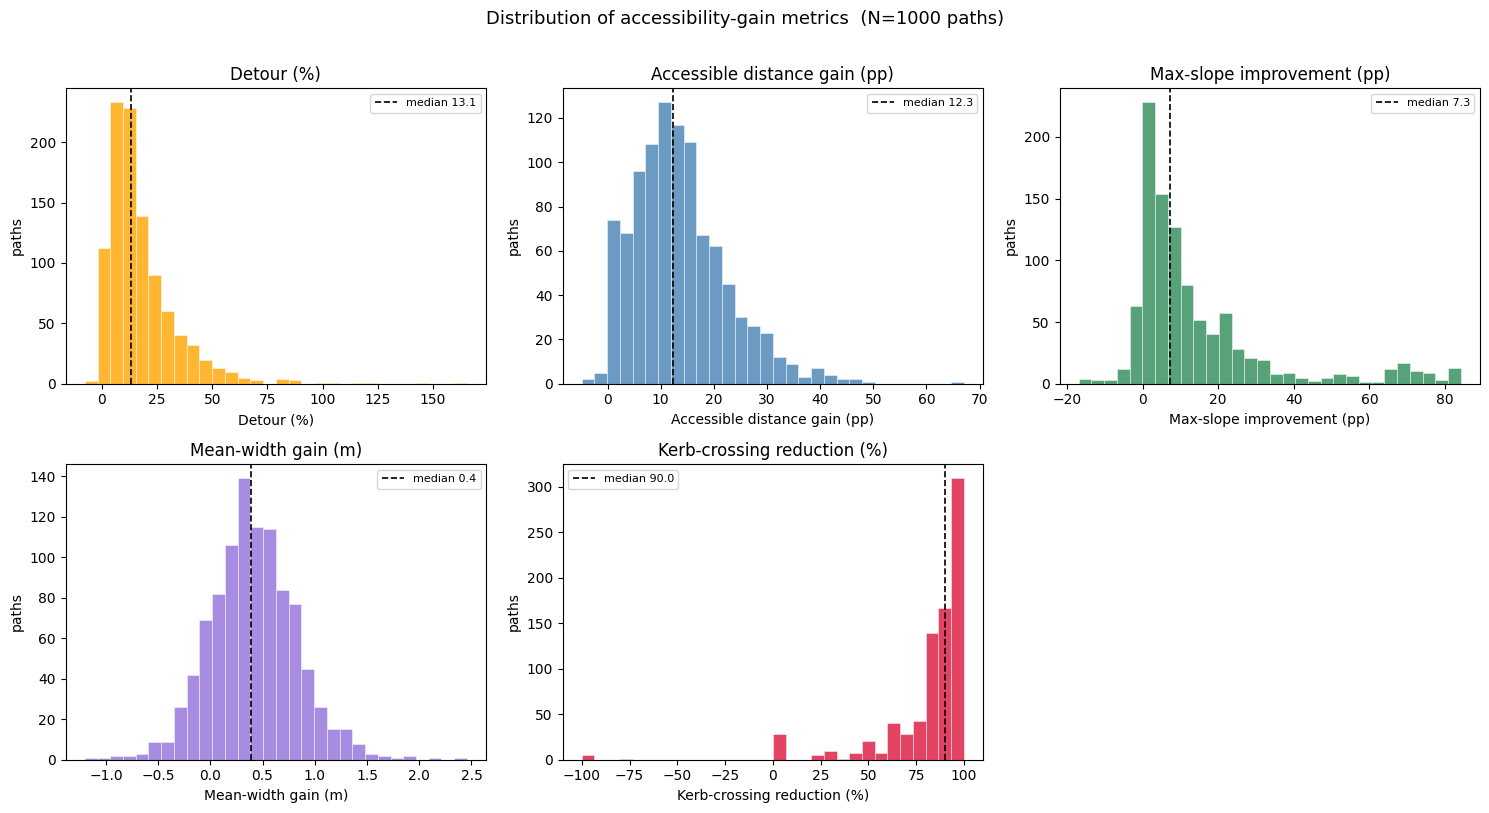

In [6]:
ncols = 3
plot_specs = [
    ("detour_pct",          "Detour (%)",                       "orange"),
    ("acc_dist_gain_pp",    "Accessible distance gain (pp)",    "steelblue"),
    ("slope_improvement_pp","Max-slope improvement (pp)",       "seagreen"),
    ("width_gain_m",        "Mean-width gain (m)",              "mediumpurple"),
]
if HAS_KERB_CROSS:
    plot_specs.append(("kerb_reduction_pct", "Kerb-crossing reduction (%)", "crimson"))

nrows = (len(plot_specs) + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axs = np.array(axs).flatten()

for ax, (col, label, color) in zip(axs, plot_specs):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    med = data.median()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.2,
               label=f"median {med:.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("paths")
    ax.legend(fontsize=8)
    ax.set_title(label)

for ax in axs[len(plot_specs):]:
    ax.set_visible(False)

fig.suptitle(f"Distribution of accessibility-gain metrics  (N={len(df)} paths)",
             fontsize=13, y=1.01)
plt.tight_layout()

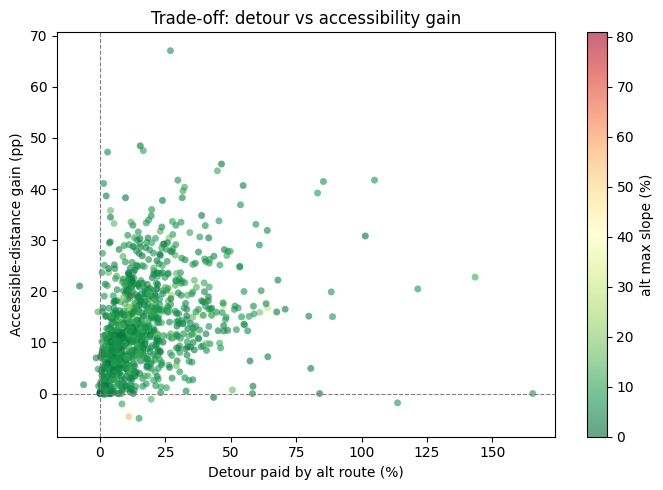

In [7]:
# Detour vs accessible-distance gain — the core trade-off scatter
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    df["detour_pct"],
    df["acc_dist_gain_pp"],
    c=df["alt_max_slope_pct"] if "alt_max_slope_pct" in df else "steelblue",
    cmap="RdYlGn_r",
    alpha=0.6,
    edgecolors="none",
    s=25,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("alt max slope (%)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Detour paid by alt route (%)")
ax.set_ylabel("Accessible-distance gain (pp)")
ax.set_title("Trade-off: detour vs accessibility gain")
plt.tight_layout()

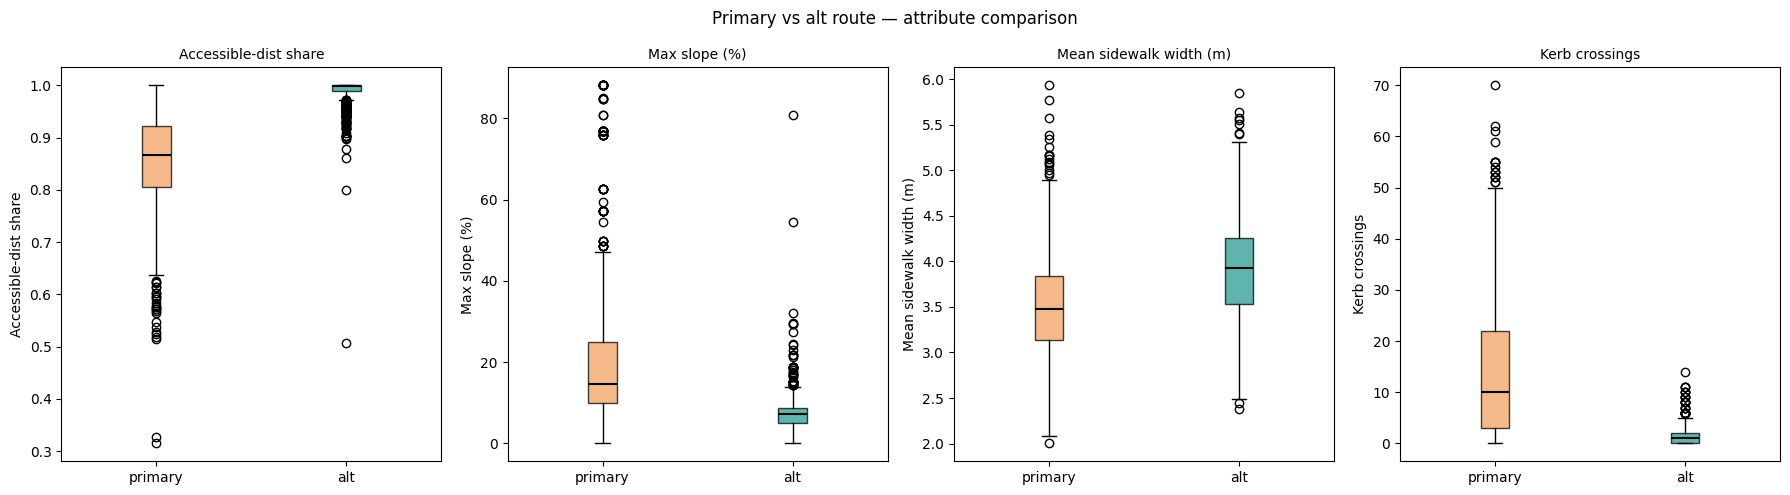

In [8]:
# Side-by-side boxplots: primary vs alt for each attribute
compare_pairs = [
    ("prim_acc_dist_frac",   "alt_acc_dist_frac",   "Accessible-dist share",  True),
    ("prim_max_slope_pct",   "alt_max_slope_pct",   "Max slope (%)",          False),
    ("prim_mean_width_m",    "alt_mean_width_m",    "Mean sidewalk width (m)",True),
]
if HAS_KERB_CROSS:
    compare_pairs.append(
        ("prim_kerb_crossings", "alt_kerb_crossings", "Kerb crossings", False)
    )

fig, axs = plt.subplots(1, len(compare_pairs), figsize=(4.5 * len(compare_pairs), 5))

for ax, (pc, ac, label, higher_is_better) in zip(axs, compare_pairs):
    bp = ax.boxplot(
        [df[pc].dropna(), df[ac].dropna()],
        labels=["primary", "alt"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
    )
    colors = ["#f4a261", "#2a9d8f"]
    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label)

fig.suptitle("Primary vs alt route — attribute comparison", fontsize=12)
plt.tight_layout()

## 6 · KPIs

In [9]:
# ── KPI 0: Baseline Accessibility Rate (BAR) ─────────────────────────────────
# Median % of accessible distance on distance-optimal (shortest) routes.
# Model-independent: tells you how accessible the city already is for a
# typical walker who just takes the shortest path.
BAR = df["prim_acc_dist_frac"].median() * 100

# ── KPI 0b: Network Accessibility Ratio (NAR) ────────────────────────────────
# % of total network sidewalk length that is classified as accessible.
# Infrastructure-level metric: independent of routing and of the sampled paths.
total_len = edges_gdf["distance"].sum()
acc_len   = edges_gdf.loc[edges_gdf["accesibility"] == 1, "distance"].sum()
NAR = acc_len / total_len * 100

# ── KPI 1: Accessibility Gain Rate (AGR) ─────────────────────────────────────
# Median relative % increase in accessible distance on the alt route vs the
# primary route: (alt − prim) / prim × 100.
AGR = df["acc_dist_gain_pct"].median()

# ── KPI 2: Kerb Avoidance Rate (KAR) ─────────────────────────────────────────
# Median % reduction in kerb crossings on the alt route among paths where the
# primary route crossed at least one kerb.
if HAS_KERB_CROSS:
    KAR = df.loc[df["prim_kerb_crossings"] > 0, "kerb_reduction_pct"].median()
else:
    KAR = float("nan")
    print("KAR: kerb_cross column not present — re-run initialize with the valencia overlay block.")

# ── KPI 3: Cost of Accessibility (CoA) ───────────────────────────────────────
# Median detour (%) paid by the alt route to achieve a positive accessibility
# gain.
CoA = df.loc[df["acc_dist_gain_pct"] > 0, "detour_pct"].median()

print("═" * 52)
print("  City-level accessibility")
print(f"  BAR — Baseline Accessibility Rate : {BAR:6.1f} %")
print(f"  NAR — Network Accessibility Ratio : {NAR:6.1f} %")
print("  ─────────────────────────────────────────────")
print("  Model gain")
print(f"  AGR — Accessibility Gain Rate     : {AGR:+6.1f} %")
print(f"  KAR — Kerb Avoidance Rate         : {KAR:+6.1f} %")
print(f"  CoA — Cost of Accessibility       : {CoA:+6.1f} %")
print("═" * 52)
print()
print(f"Interpretation (N={len(df)} paths):")
print(f"  • {BAR:.1f}% of a typical shortest route is accessible (no optimisation).")
print(f"  • {NAR:.1f}% of all network sidewalk length is classified as accessible.")
print(f"  • The alt route gains {AGR:+.1f}% of accessible distance relative to the baseline.")
if not np.isnan(KAR):
    n_kerb = int((df["prim_kerb_crossings"] > 0).sum())
    print(f"  • Among {n_kerb} paths with kerb crossings, the alt route reduces them by {KAR:.0f}%.")
print(f"  • Where a gain is achieved, the median extra distance is {CoA:.1f}%.")

════════════════════════════════════════════════════
  City-level accessibility
  BAR — Baseline Accessibility Rate :   86.6 %
  NAR — Network Accessibility Ratio :   77.0 %
  ─────────────────────────────────────────────
  Model gain
  AGR — Accessibility Gain Rate     :  +14.2 %
  KAR — Kerb Avoidance Rate         :  +90.0 %
  CoA — Cost of Accessibility       :  +13.2 %
════════════════════════════════════════════════════

Interpretation (N=1000 paths):
  • 86.6% of a typical shortest route is accessible (no optimisation).
  • 77.0% of all network sidewalk length is classified as accessible.
  • The alt route gains +14.2% of accessible distance relative to the baseline.
  • Among 811 paths with kerb crossings, the alt route reduces them by 90%.
  • Where a gain is achieved, the median extra distance is 13.2%.


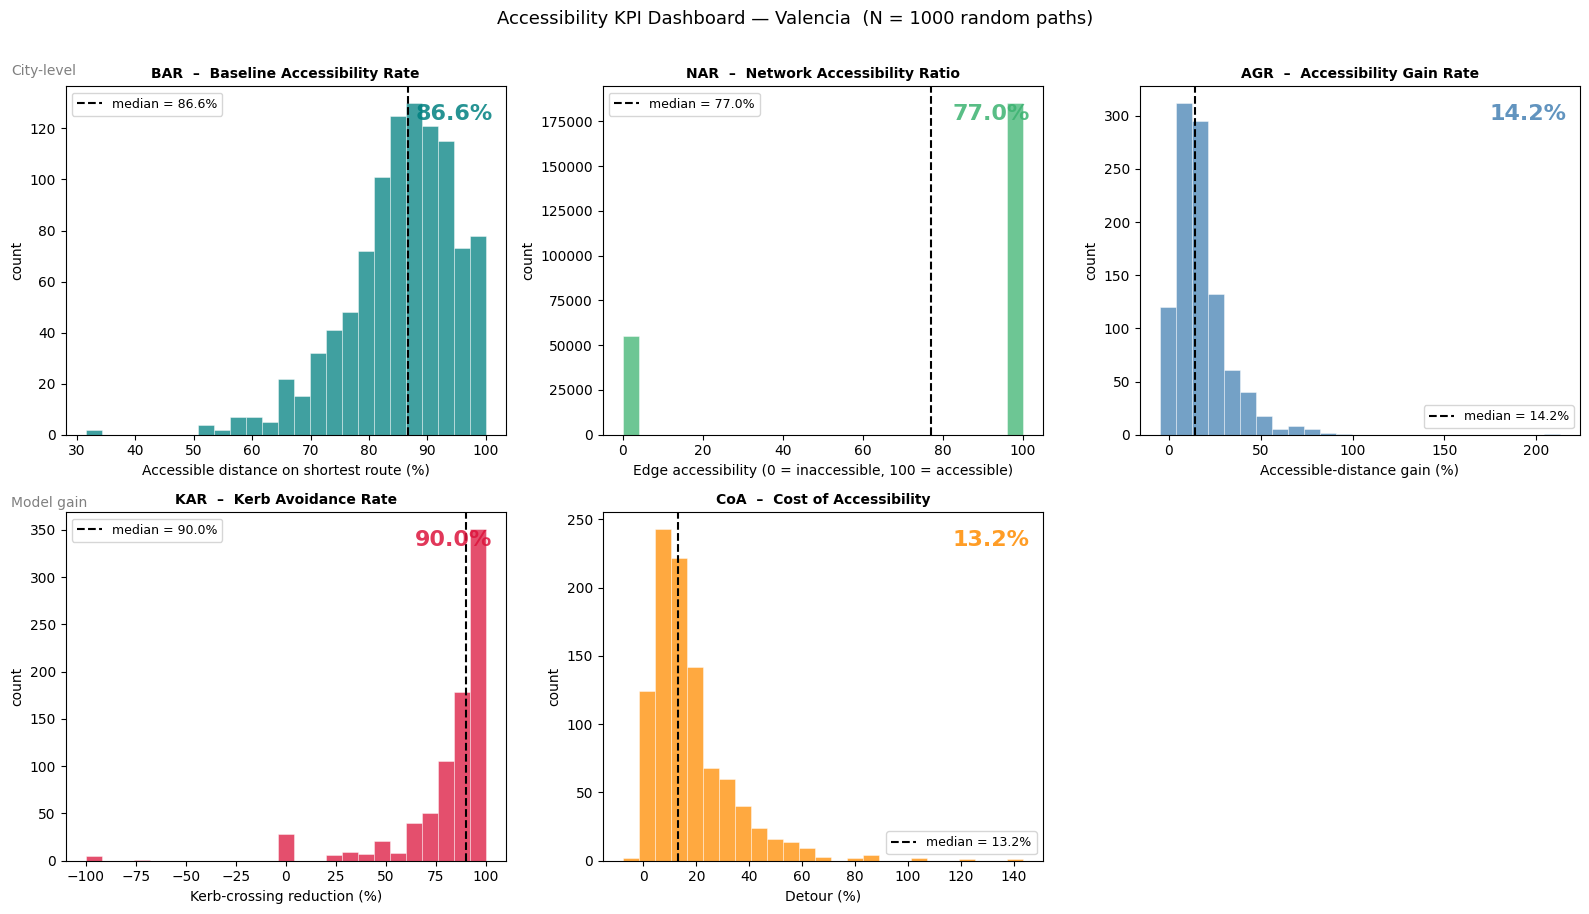

In [10]:
# ── KPI dashboard (2 × 3 grid) ────────────────────────────────────────────────
fig, axs = plt.subplots(2, 3, figsize=(16, 9))
axs = axs.flatten()

# City-level KPIs use the full distribution of baseline paths / all edges.
# Model-gain KPIs use the gain distributions as before.
kpi_specs = [
    # (data_series_or_array, title, xlabel, kpi_value, bar_color)
    (
        df["prim_acc_dist_frac"] * 100,
        "BAR  –  Baseline Accessibility Rate",
        "Accessible distance on shortest route (%)",
        BAR, "teal",
    ),
    (
        edges_gdf["accesibility"] * 100,
        "NAR  –  Network Accessibility Ratio",
        "Edge accessibility (0 = inaccessible, 100 = accessible)",
        NAR, "mediumseagreen",
    ),
    (
        df["acc_dist_gain_pct"].dropna(),
        "AGR  –  Accessibility Gain Rate",
        "Accessible-distance gain (%)",
        AGR, "steelblue",
    ),
    (
        df.loc[df["prim_kerb_crossings"] > 0, "kerb_reduction_pct"] if HAS_KERB_CROSS else df["acc_edge_gain_pp"],
        "KAR  –  Kerb Avoidance Rate" if HAS_KERB_CROSS else "Edge accessibility gain (%)",
        "Kerb-crossing reduction (%)" if HAS_KERB_CROSS else "Accessible-edge gain (%)",
        KAR if HAS_KERB_CROSS else df["acc_edge_gain_pp"].median(),
        "crimson",
    ),
    (
        df.loc[df["acc_dist_gain_pct"] > 0, "detour_pct"],
        "CoA  –  Cost of Accessibility",
        "Detour (%)",
        CoA, "darkorange",
    ),
]

for ax, (data, title, xlabel, kpi_val, color) in zip(axs, kpi_specs):
    data = data.dropna()
    ax.hist(data, bins=25, color=color, alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.axvline(kpi_val, color="black", linestyle="--", linewidth=1.5,
               label=f"median = {kpi_val:.1f}%")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    ax.legend(fontsize=9)
    ax.text(0.97, 0.95, f"{kpi_val:.1f}%",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=16, fontweight="bold", color=color, alpha=0.85)

# Label the two groups
fig.text(0.01, 0.95, "City-level", fontsize=10, color="gray", va="top")
fig.text(0.01, 0.47, "Model gain", fontsize=10, color="gray", va="top")

axs[-1].set_visible(False)  # hide empty 6th cell

fig.suptitle(
    f"Accessibility KPI Dashboard — Valencia  (N = {len(df)} random paths)",
    fontsize=13, y=1.01,
)
plt.tight_layout()